In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install pydicom albumentations grad-cam -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tmodels
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import random, time, warnings
warnings.filterwarnings('ignore')

BASE_PATH = '/content/drive/MyDrive/LungDiseaseProject/data/rsna_data/'
IMG_DIR   = BASE_PATH + 'stage_2_train_images/'
df        = pd.read_csv(BASE_PATH + 'stage_2_train_labels.csv')

patient_ids      = df['patientId'].unique()
labels_for_split = [df[df['patientId']==pid]['Target'].values[0]
                    for pid in patient_ids]
train_ids, val_ids = train_test_split(
    patient_ids, test_size=0.2,
    random_state=42, stratify=labels_for_split)
train_df = df[df['patientId'].isin(train_ids)]
val_df   = df[df['patientId'].isin(val_ids)]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("✅ Drive mounted")
print("✅ Libraries imported")
print("✅ Data loaded:", len(df), "rows")
print("✅ Train:", len(train_ids), "| Val:", len(val_ids))
print("✅ Device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted
✅ Libraries imported
✅ Data loaded: 30227 rows
✅ Train: 21347 | Val: 5337
✅ Device: cuda


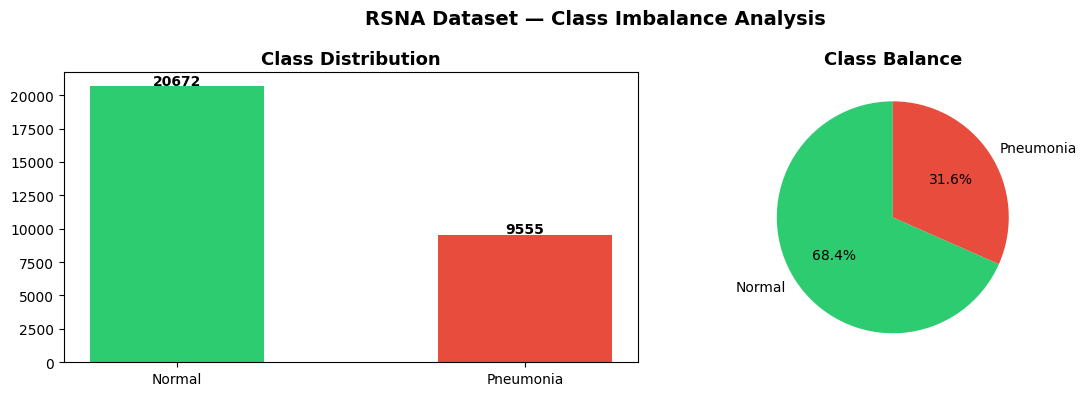

Normal:    20672 (68.4%)
Pneumonia: 9555 (31.6%)
Ratio:     2.2:1
This imbalance is handled using pos_weight in loss function


In [ ]:
counts = df['Target'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Normal', 'Pneumonia'],
            [counts[0], counts[1]],
            color=['#2ecc71', '#e74c3c'], width=0.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v+100, str(v), ha='center', fontweight='bold')

axes[1].pie([counts[0], counts[1]],
            labels=['Normal', 'Pneumonia'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.suptitle('RSNA Dataset — Class Imbalance Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Normal:    {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"Pneumonia: {counts[1]} ({counts[1]/len(df)*100:.1f}%)")
print(f"Ratio:     {counts[0]/counts[1]:.1f}:1")
print("This imbalance is handled using pos_weight in loss function")

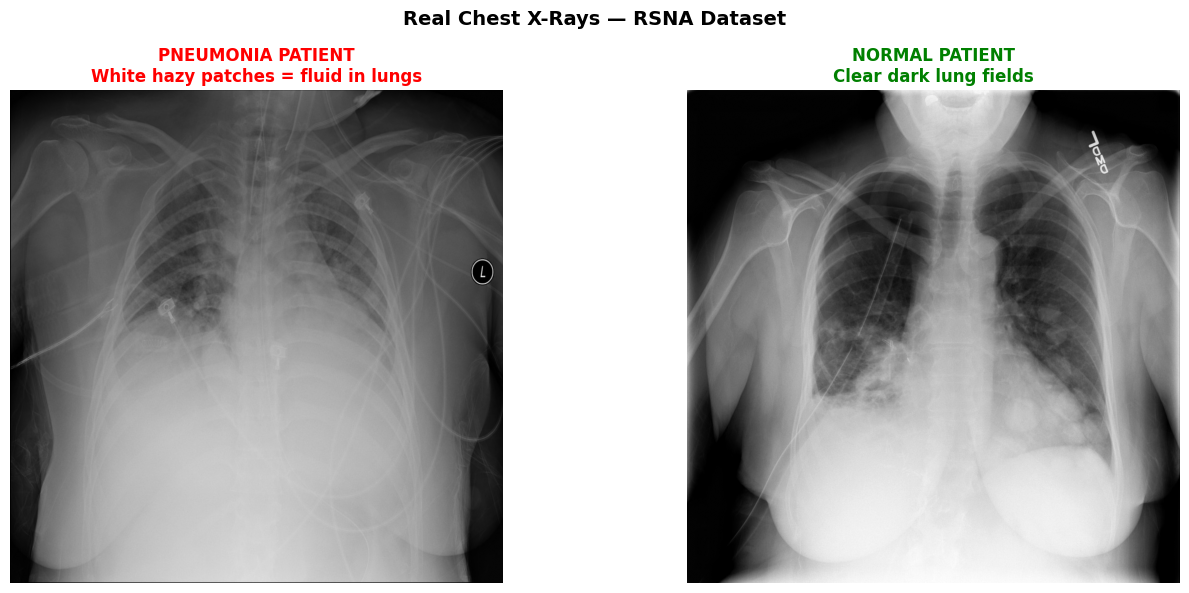

Image shape: (1024, 1024)
Pixel range: 0 to 255


In [ ]:
pneumonia_id = df[df['Target']==1].iloc[0]['patientId']
normal_id    = df[df['Target']==0].iloc[0]['patientId']

pneumonia_img = pydicom.dcmread(IMG_DIR + pneumonia_id + '.dcm').pixel_array
normal_img    = pydicom.dcmread(IMG_DIR + normal_id   + '.dcm').pixel_array

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(pneumonia_img, cmap='gray')
axes[0].set_title('PNEUMONIA PATIENT\nWhite hazy patches = fluid in lungs',
                   color='red', fontsize=12, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(normal_img, cmap='gray')
axes[1].set_title('NORMAL PATIENT\nClear dark lung fields',
                   color='green', fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.suptitle('Real Chest X-Rays — RSNA Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Image shape:", pneumonia_img.shape)
print("Pixel range:", pneumonia_img.min(), "to", pneumonia_img.max())

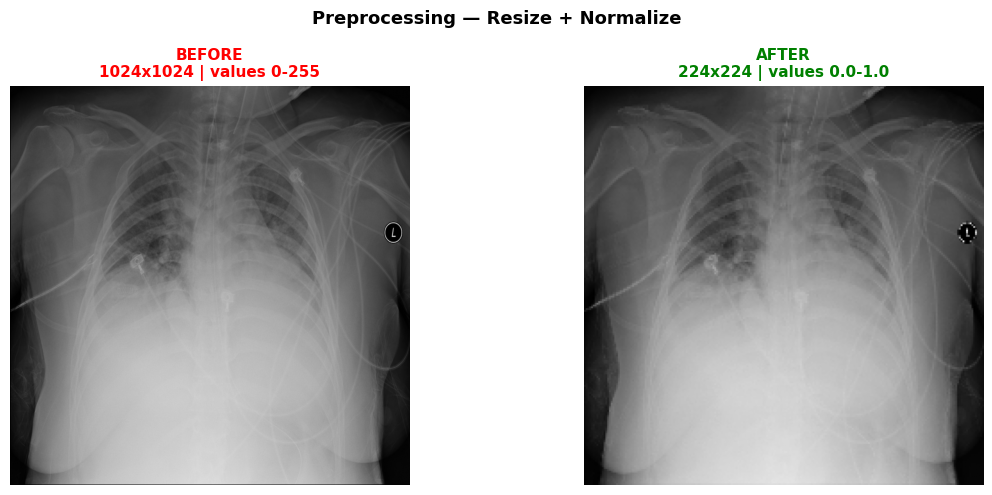

In [ ]:
sample_img  = pydicom.dcmread(IMG_DIR + pneumonia_id + '.dcm').pixel_array
img_resized = cv2.resize(sample_img, (224, 224))
img_norm    = (img_resized / 255.0).astype(np.float32)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title('BEFORE\n1024x1024 | values 0-255',
                   color='red', fontsize=11, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(img_norm, cmap='gray')
axes[1].set_title('AFTER\n224x224 | values 0.0-1.0',
                   color='green', fontsize=11, fontweight='bold')
axes[1].axis('off')
plt.suptitle('Preprocessing — Resize + Normalize',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

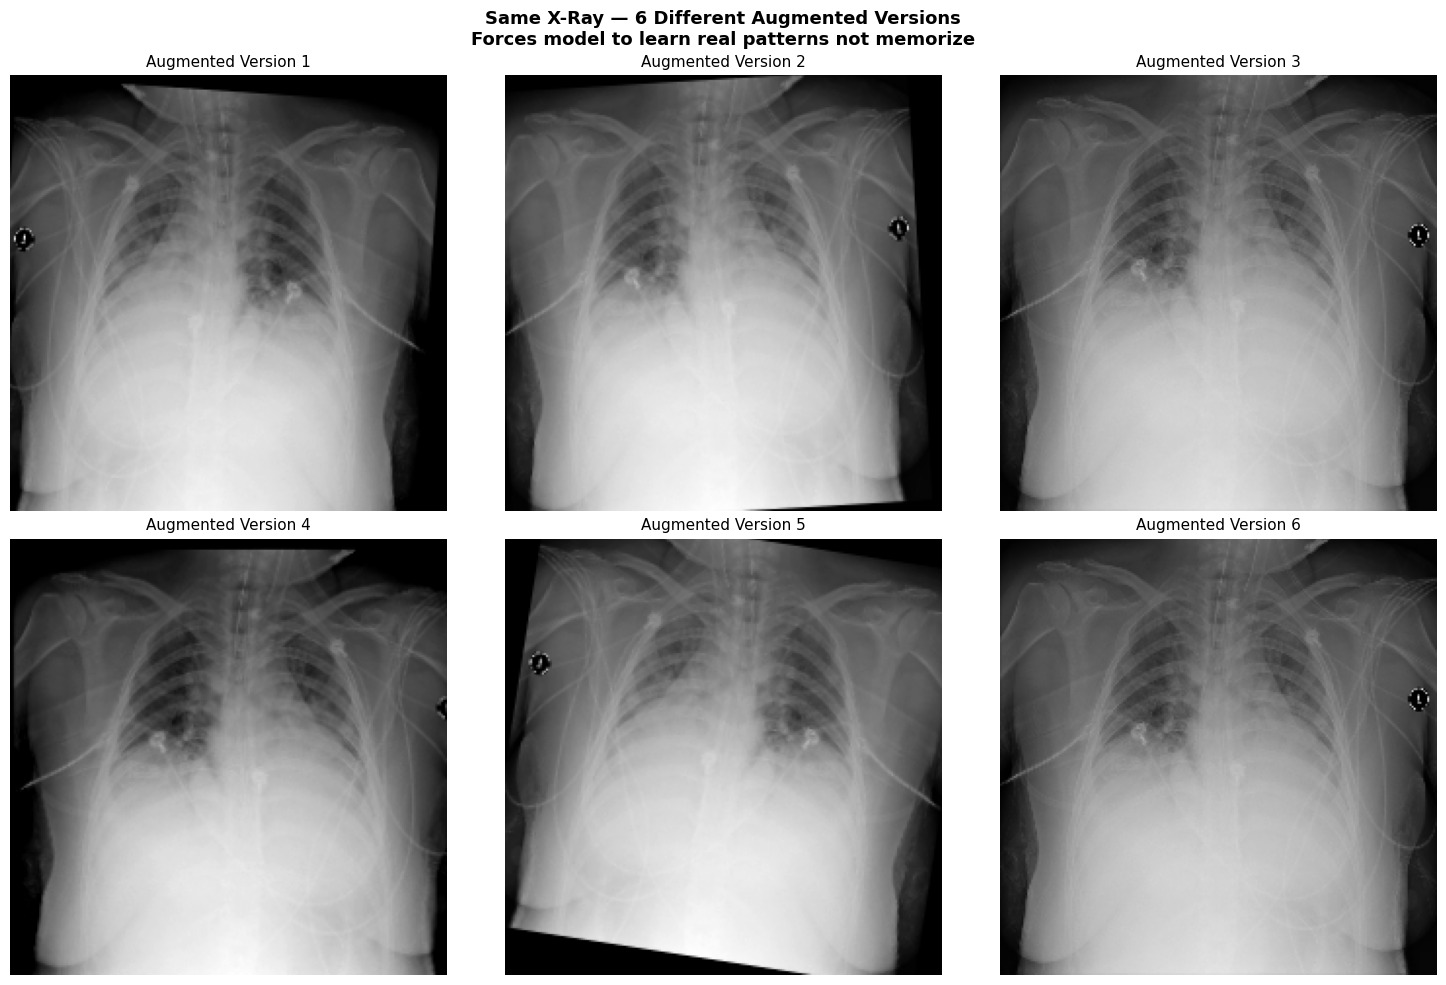

In [ ]:
augmentation = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05,
                       scale_limit=0.05,
                       rotate_limit=10, p=0.5),
])

img_rgb = np.stack([img_resized]*3, axis=-1)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(6):
    aug = augmentation(image=img_rgb)['image']
    axes[i].imshow(aug[:,:,0], cmap='gray')
    axes[i].set_title(f'Augmented Version {i+1}', fontsize=11)
    axes[i].axis('off')

plt.suptitle('Same X-Ray — 6 Different Augmented Versions\n'
             'Forces model to learn real patterns not memorize',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05,
                       scale_limit=0.05,
                       rotate_limit=10, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])
val_transform = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

class RSNADataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df          = dataframe
        self.img_dir     = img_dir
        self.transform   = transform
        self.patient_ids = dataframe['patientId'].unique()

    def __len__(self):
        return len(self.patient_ids)

    def __getitem__(self, idx):
        patient_id = self.patient_ids[idx]
        label = self.df[
            self.df['patientId']==patient_id
        ]['Target'].values[0]
        image = pydicom.dcmread(
            self.img_dir + patient_id + '.dcm'
        ).pixel_array
        image = cv2.resize(image, (224, 224))
        image = np.stack([image, image, image], axis=-1)
        if self.transform:
            image = self.transform(image=image)['image']
        return image, torch.tensor(label, dtype=torch.float32)

train_dataset = RSNADataset(train_df, IMG_DIR, train_transform)
val_dataset   = RSNADataset(val_df,   IMG_DIR, val_transform)
train_loader  = DataLoader(train_dataset, batch_size=32,
                           shuffle=True,  num_workers=2)
val_loader    = DataLoader(val_dataset,   batch_size=32,
                           shuffle=False, num_workers=2)

print("✅ Transforms ready!")
print("✅ Datasets ready!")
print(f"✅ Train: {len(train_dataset)} | Val: {len(val_dataset)}")
print(f"✅ Train batches: {len(train_loader)}")

✅ Transforms ready!
✅ Datasets ready!
✅ Train: 21347 | Val: 5337
✅ Train batches: 668


In [ ]:
class PneumoniaModel(nn.Module):
    def __init__(self):
        super(PneumoniaModel, self).__init__()
        self.densenet = tmodels.densenet121(pretrained=False)
        num_features  = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Linear(num_features, 1)

    def forward(self, x):
        return self.densenet(x)

model = PneumoniaModel().to(device)
model.load_state_dict(
    torch.load(
        '/content/drive/MyDrive/LungDiseaseProject/best_model.pth',
        map_location=device
    )
)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print("✅ Trained model loaded!")
print(f"✅ Parameters: {total_params:,}")
print(f"✅ Running on: {device}")
print("✅ No retraining needed — using saved weights!")

✅ Trained model loaded!
✅ Parameters: 6,954,881
✅ Running on: cuda
✅ No retraining needed — using saved weights!


In [ ]:
# Continue training from saved model
# Lower learning rate because model already learned basics
normal_count    = (train_df['Target']==0).sum()
pneumonia_count = (train_df['Target']==1).sum()
pos_weight = torch.tensor(
    [normal_count/pneumonia_count]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.00005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, all_labels, all_preds = 0, [], []
    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images).squeeze(1)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(
            torch.sigmoid(outputs).detach().cpu().numpy())
        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx}/{len(loader)} "
                  f"Loss: {loss.item():.4f}")
    return (total_loss/len(loader),
            roc_auc_score(all_labels, all_preds))

def validate(model, loader, criterion, device):
    model.eval()
    total_loss, all_labels, all_preds = 0, [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze(1)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(
                torch.sigmoid(outputs).detach().cpu().numpy())
    return (total_loss/len(loader),
            roc_auc_score(all_labels, all_preds))

# Train 10 more epochs
NUM_EPOCHS   = 10
best_val_auc = 0.8849  # our previous best
save_path    = '/content/drive/MyDrive/LungDiseaseProject/best_model_v2.pth'

print("🚀 Continuing Training — 10 More Epochs!")
print(f"Starting from AUC: {best_val_auc}")
print("=" * 50)

for epoch in range(NUM_EPOCHS):
    start_time = time.time()
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 30)

    train_loss, train_auc = train_one_epoch(
        model, train_loader, criterion, optimizer, device)
    val_loss, val_auc = validate(
        model, val_loader, criterion, device)
    scheduler.step(val_loss)

    epoch_time = time.time() - start_time
    gap        = abs(train_auc - val_auc)

    print(f"\nEpoch {epoch+1} Results:")
    print(f"  Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}   | Val AUC:   {val_auc:.4f}")
    print(f"  Overfit Gap: {gap:.4f} "
          f"{'✅ Good' if gap < 0.05 else '⚠️ Watch this'}")
    print(f"  Time: {epoch_time/60:.1f} minutes")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), save_path)
        print(f"  ✅ New best! Val AUC: {val_auc:.4f} — Saved!")
    else:
        print(f"  No improvement. Best still: {best_val_auc:.4f}")

print("\n" + "=" * 50)
print(f"🎉 Training Complete!")
print(f"Best Val AUC: {best_val_auc:.4f}")

🚀 Continuing Training — 10 More Epochs!
Starting from AUC: 0.8849

Epoch 1/10
------------------------------
  Batch 0/668 Loss: 0.4030
  Batch 100/668 Loss: 0.3966
  Batch 200/668 Loss: 0.7948
  Batch 300/668 Loss: 0.3880
  Batch 400/668 Loss: 0.3299
  Batch 500/668 Loss: 0.8761
  Batch 600/668 Loss: 0.6528

Epoch 1 Results:
  Train Loss: 0.4730 | Train AUC: 0.9065
  Val Loss:   0.5310   | Val AUC:   0.8837
  Overfit Gap: 0.0229 ✅ Good
  Time: 41.4 minutes
  No improvement. Best still: 0.8849

Epoch 2/10
------------------------------
  Batch 0/668 Loss: 0.5067
  Batch 100/668 Loss: 0.5721
  Batch 200/668 Loss: 0.5720
  Batch 300/668 Loss: 0.6775
  Batch 400/668 Loss: 0.7897
  Batch 500/668 Loss: 0.1744
  Batch 600/668 Loss: 0.5040

Epoch 2 Results:
  Train Loss: 0.4378 | Train AUC: 0.9204
  Val Loss:   0.5445   | Val AUC:   0.8851
  Overfit Gap: 0.0353 ✅ Good
  Time: 6.6 minutes
  ✅ New best! Val AUC: 0.8851 — Saved!

Epoch 3/10
------------------------------
  Batch 0/668 Loss: 0.35

KeyboardInterrupt: 

In [1]:
# Step 1 - Mount Drive first
from google.colab import drive
drive.mount('/content/drive')

import os

# Step 2 - Check all files in project folder
project_path = '/content/drive/MyDrive/LungDiseaseProject/'
print("Files in your project folder:")
for f in os.listdir(project_path):
    size = os.path.getsize(project_path + f) / (1024*1024)
    print(f"  {f} — {size:.1f} MB")

Mounted at /content/drive
Files in your project folder:
  data — 0.0 MB
  best_model.pth — 27.1 MB
  best_model_v2.pth — 27.1 MB


In [2]:
import os
models = [
    '/content/drive/MyDrive/LungDiseaseProject/best_model.pth',
    '/content/drive/MyDrive/LungDiseaseProject/best_model_v2.pth',
]
for m in models:
    if os.path.exists(m):
        size = os.path.getsize(m)/(1024*1024)
        print(f"✅ {m.split('/')[-1]} — {size:.1f} MB")
    else:
        print(f"❌ {m.split('/')[-1]} — not found")


✅ best_model.pth — 27.1 MB
✅ best_model_v2.pth — 27.1 MB


In [ ]:
!pip install pydicom grad-cam -q
print("Done!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 41.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 111.7 MB/s eta 0:00:00
Done!


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as tmodels
import pydicom
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = '/content/drive/MyDrive/LungDiseaseProject/data/rsna_data/'
IMG_DIR   = BASE_PATH + 'stage_2_train_images/'
df        = pd.read_csv(BASE_PATH + 'stage_2_train_labels.csv')
device    = torch.device('cpu')

class PneumoniaModel(nn.Module):
    def __init__(self):
        super(PneumoniaModel, self).__init__()
        self.densenet = tmodels.densenet121(pretrained=False)
        num_features  = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Linear(num_features, 1)
    def forward(self, x):
        return self.densenet(x)

# Load best model v2
model = PneumoniaModel()
model.load_state_dict(
    torch.load(
        '/content/drive/MyDrive/LungDiseaseProject/best_model_v2.pth',
        map_location=device))
model.eval()
print("✅ Best model v2 loaded! AUC 0.8853")

def predict(patient_id):
    image         = pydicom.dcmread(IMG_DIR + patient_id + '.dcm').pixel_array
    image_resized = cv2.resize(image, (224, 224))
    image_rgb     = np.stack([image_resized]*3, axis=-1)
    mean          = np.array([0.485, 0.456, 0.406])
    std           = np.array([0.229, 0.224, 0.225])
    image_norm    = (image_rgb/255.0 - mean) / std
    image_tensor  = torch.tensor(
        image_norm.transpose(2,0,1),
        dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        prob = torch.sigmoid(model(image_tensor)).item()
    return image_resized, image_rgb, image_tensor, prob

def show_gradcam(patient_id, actual_label, sample_num=None):
    image_resized, image_rgb, image_tensor, prob = predict(patient_id)
    target_layer  = [model.densenet.features[-1]]
    cam           = GradCAM(model=model, target_layers=target_layer)
    grayscale_cam = cam(input_tensor=image_tensor)[0]
    original_img  = (image_rgb/255.0).astype(np.float32)
    visualization = show_cam_on_image(original_img, grayscale_cam, use_rgb=True)
    predicted     = 'PNEUMONIA' if prob > 0.5 else 'NORMAL'
    is_correct    = predicted == actual_label
    color         = 'green' if is_correct else 'red'

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].imshow(image_resized, cmap='gray')
    axes[0].set_title(f'Sample {sample_num} — Original\nActual: {actual_label}',
                      fontsize=12, fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(visualization)
    axes[1].set_title(
        f'Grad-CAM\nPredicted: {predicted} ({prob*100:.1f}%)\n'
        f'{"✅ CORRECT" if is_correct else "❌ WRONG"}',
        fontsize=12, color=color, fontweight='bold')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    return is_correct, prob

print("✅ Functions ready!")

✅ Best model v2 loaded! AUC 0.8853
✅ Functions ready!


In [ ]:
random.seed(128)

pneumonia_ids    = df[df['Target']==1]['patientId'].unique()
normal_ids       = df[df['Target']==0]['patientId'].unique()
sample_pneumonia = random.sample(list(pneumonia_ids), 5)
sample_normal    = random.sample(list(normal_ids), 5)
all_samples      = (
    [(pid, 'PNEUMONIA') for pid in sample_pneumonia] +
    [(pid, 'NORMAL')    for pid in sample_normal])
random.shuffle(all_samples)

correct = 0
results = []

print("Testing 10 random samples with BEST MODEL v2...")
print("=" * 50)

for i, (patient_id, actual_label) in enumerate(all_samples):
    print(f"\nSample {i+1}/10")
    is_correct, prob = show_gradcam(patient_id, actual_label, i+1)
    predicted = 'PNEUMONIA' if prob > 0.5 else 'NORMAL'
    if is_correct:
        correct += 1
    results.append({
        'Sample'    : i+1,
        'Actual'    : actual_label,
        'Predicted' : predicted,
        'Confidence': f"{prob*100:.1f}%",
        'Result'    : '✅' if is_correct else '❌'
    })

print("\n" + "=" * 50)
print("FINAL RESULTS")
print("=" * 50)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print("=" * 50)
print(f"Correct:  {correct}/10")
print(f"Accuracy: {correct*10}%")
print(f"Model:    best_model_v2.pth (AUC 0.8853)")


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import torch

model.load_state_dict(torch.load("/content/drive/MyDrive/LungDiseaseProject/best_model_v2.pth"))
model.eval()

PneumoniaModel(
  (densenet): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, mome

In [ ]:
from PIL import Image
import torchvision.transforms as transforms
from google.colab import files
import torch

# Upload image
uploaded = files.upload()

# Automatically get file name
image_path = list(uploaded.keys())[0]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(input_tensor)
    prob = torch.sigmoid(output).item()

prediction = "PNEUMONIA" if prob > 0.5 else "NORMAL"

print(f"Prediction: {prediction}")
print(f"Confidence: {prob:.4f}")

IndexError: list index out of range

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

models = [
    '/content/drive/MyDrive/LungDiseaseProject/best_model.pth',
    '/content/drive/MyDrive/LungDiseaseProject/best_model_15epochs.pth',
    '/content/drive/MyDrive/LungDiseaseProject/best_model_v2.pth',
]

for m in models:
    if os.path.exists(m):
        size = os.path.getsize(m)/(1024*1024)
        print(f"✅ {m.split('/')[-1]} — {size:.1f} MB")
    else:
        print(f"❌ {m.split('/')[-1]} — not found")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ best_model.pth — 27.1 MB
❌ best_model_15epochs.pth — not found
✅ best_model_v2.pth — 27.1 MB
